
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> Linear Regression </h2>
</div>

### Linear regression

- Linear regression analysus is a powerful technique used for predicting unknown value of a variable(Dependent variable) from the known values of another variables(Independent variable)
- Here output value is continous and numerical value
- It is used to show the linear relationship between a dependent variable and one or more independent variables.

### Regression Line:	
- Regression line is simply a single line that best fits the data(in terms of having smallest overall distance from the line to the points)
- This technique is used for finding the "best fitting line" using the "Least squares method"


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


## BOSTON DATA
Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000 
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in $1000's

    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of UCI ML housing dataset.
https://archive.ics.uci.edu/ml/machine-learning-databases/housing/


This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University.

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.

The Boston house-price data has been used in many machine learning papers that address regression
problems.   
     
.. topic:: References

   - Belsley, Kuh & Welsch, 'Regression diagnostics: Identifying Influential Data and Sources of Collinearity', Wiley, 1980. 244-261.
   - Quinlan,R. (1993). Combining Instance-Based and Model-Based Learning. In Proceedings on the Tenth International Conference of Machine Learning, 236-243, University of Massachusetts, Amherst. Morgan Kaufmann.

##### Here  - " MED- Median value of owner-occupied homes in $1000's"   is the output column

## 1. Import all Librariy

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [23]:
# collecting the data
bos_data = pd.read_csv('../Dataset/BostonHousing.csv')
bos_data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Here we have downloaded data, but we can directly access from sklearn library
from sklearn.datasets import load_boston


boston = load_boston()      #Load the data 

boston.keys()               # it provides key detail  : dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])

print(boston.DESCR)         # To see column Description and abt file

boston.feature_names         # To see ip column name as array

data = boston.data 
data = pd.DataFrame(data = data, columns= boston.feature_names)      # To assign ip colum data

data['Price'] = boston.target   # To assign op colum data as new column



## 2. Data Exploration with Graphs and Visualization  -  EDA
Analysing features with the target column

In [24]:
bos_data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677082,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [25]:
bos_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
crim       506 non-null float64
zn         506 non-null float64
indus      506 non-null float64
chas       506 non-null int64
nox        506 non-null float64
rm         506 non-null float64
age        506 non-null float64
dis        506 non-null float64
rad        506 non-null int64
tax        506 non-null int64
ptratio    506 non-null float64
b          506 non-null float64
lstat      506 non-null float64
medv       506 non-null float64
dtypes: float64(11), int64(3)
memory usage: 55.4 KB


In [26]:

bos_data.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [27]:
## Heat MAP
X = bos_data.iloc[:,0:13]
correlation = X.corr()
correlation

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993


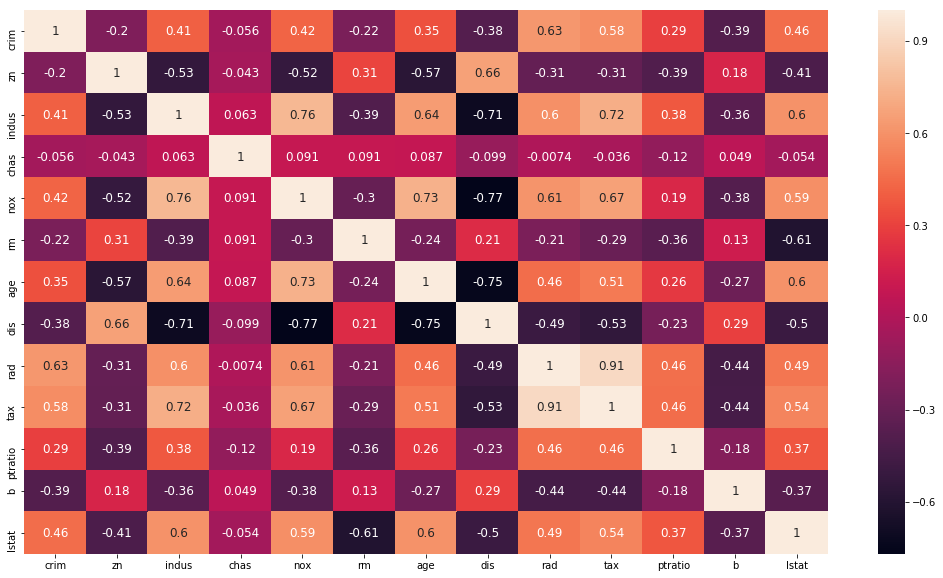

In [28]:
fig, ax = plt.subplots(figsize = (18, 10))
sns.heatmap(correlation, annot = True, annot_kws={'size': 12})
plt.show()

In [29]:
correlation.index.values

array(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad',
       'tax', 'ptratio', 'b', 'lstat'], dtype=object)

In [30]:
X = bos_data.iloc[:,0:13]
Y = bos_data['medv']
X.head()  # only input data i.e Independent variable

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [31]:
Y.head() # Dependent variable i.e Known O/P Data

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

## 3. Missing Data handling

In [32]:
print(X.isnull().sum())
## No null value

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64


# 4. Building Machine Learning Linear Models

In [33]:
# split the data into training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test  = train_test_split(X,Y,test_size=0.30,
                                                    random_state=5)

In [34]:
# using the model
from sklearn.linear_model import LinearRegression

# instantiate the model
lr_model = LinearRegression()

# train the model
lr_model.fit(x_train, y_train)
#print(x_test)
# testing or prediction
y_pred = lr_model.predict(x_test)

# compare the house price predicted vs known test value
data = {'predicted O/P':y_pred,'known(testing) O/P':y_test}
pd.DataFrame(data).head()

,predicted O/P,known(testing) O/P
226,37.389977,37.6
292,31.567942,27.9
90,27.133739,22.6
373,6.551176,13.8
273,33.693108,35.2


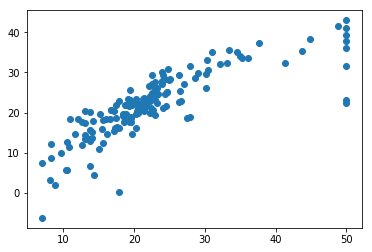

In [35]:
plt.scatter(y_test, y_pred)
#It should come as a diagnol line, so that means predicted and actual values are same

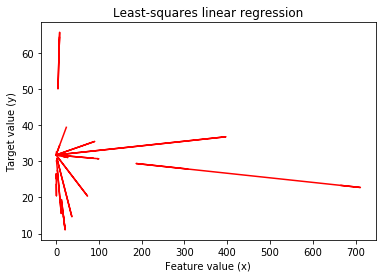

In [38]:
#X vs predicted Y plot
import matplotlib.pyplot as plt

#Here X axis is X value, Y axis is linear model formula Y= Coeff*X + Intercept
plt.plot(x_test,   lr_model.coef_ * x_test + lr_model.intercept_ ,  'r-')
plt.title('Least-squares linear regression')
plt.xlabel('Feature value (x)')
plt.ylabel('Target value (y)')
plt.show()


## 5. Model Evaluation


In [15]:
print(lr_model.score(x_train,y_train))  # it provides score
print(lr_model.score(x_test,y_test))  # it provides score

0.7611598772034452
0.6771696999851703


In [16]:
from sklearn import metrics
# accuracy_score can be used for logistic regression, cant be used in linear regression
#LInear regression SCORE and Logistic regressoion scores are totally different. Accuracy_score used for discrete or categorial output
metrics.accuracy_score(y_test, y_pred)

ValueError: continuous is not supported

In [17]:
# MAE RMSE, MSE are only used if o/p is continous numeric value not for categorial o/p means for Linear regression problem. Not for Logistic regression not for categorial o/p

## This Error should be less
#Print Mean Absolute Error MAE
print("MAE :" , metrics.mean_absolute_error(y_test, y_pred))

#Print Mean Squared Error MSE
print("MSE :" , metrics.mean_squared_error(y_test, y_pred))

#Print Root Mean Squared Error RMSE
print("RMSE :" , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


MAE : 3.557668475650035
MSE : 30.697037704088462
RMSE : 5.540490745781321


## Residuals

You should have gotten a very good model with a good fit. Let's quickly explore the residuals to make sure everything was okay with our data. 

**Plot a histogram of the residuals and make sure it looks normally distributed. Use either seaborn distplot, or just plt.hist().**

>  here actual - pred will give residul plot in histogram of the residuals and make sure it looks normally distributed
#In this case its almost normally distrbuted
   > One of the condition in linear regression. 
  > 5.Normality:For any value of X, Y(O/P) is normally distributed. The residuals of the model are normally distributed.

C:\Users\prabh\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


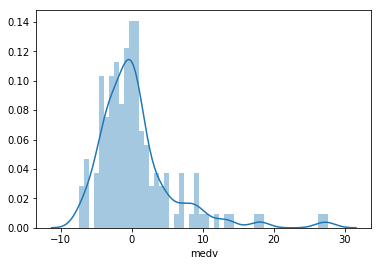

In [18]:
#Residual distplot
sns.distplot((y_test-y_pred),bins=50)
# here actual - pred will give residul plot in histogram of the residuals and make sure it looks normally distributed
#In this case its almost normally distrbuted
# One of the condition in linear regression. 
# 5.Normality:For any value of X, Y(O/P) is normally distributed. The residuals of the model are normally distributed.

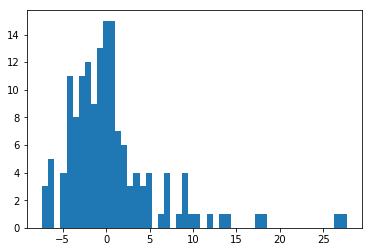

In [19]:
#Histogram
plt.hist((y_test-y_pred),bins=50)
plt.show()

### How to understand meaning of coef_ values

In [20]:
lr_model.coef_

array([-1.54486040e-01,  4.13948217e-02, -2.53765225e-02,  7.86055259e-01,
       -1.29365836e+01,  4.03952301e+00, -1.05354914e-02, -1.33498644e+00,
        3.18272501e-01, -1.26427463e-02, -9.77287564e-01,  1.26714702e-02,
       -4.62052176e-01])

In [16]:
print(lr_model.coef_)
#hERE DATAFRAME Created coef_ as column and x_train.columns as index
coeffecients = pd.DataFrame(lr_model.coef_,x_train.columns)

coeffecients.columns = ['Coeffecient']
coeffecients

[-1.54486040e-01  4.13948217e-02 -2.53765225e-02  7.86055259e-01
 -1.29365836e+01  4.03952301e+00 -1.05354914e-02 -1.33498644e+00
  3.18272501e-01 -1.26427463e-02 -9.77287564e-01  1.26714702e-02
 -4.62052176e-01]


,Coeffecient
crim,-0.154486
zn,0.041395
indus,-0.025377
chas,0.786055
nox,-12.936584
rm,4.039523
age,-0.010535
dis,-1.334986
rad,0.318273
tax,-0.012643


In [17]:
#Intercept of each feature
print('linear model intercept (b): {:.3f}'.format(lr_model.intercept_))

linear model intercept (b): 31.730


Interpreting the coefficients:

- Holding all other features fixed, a 1 unit increase in **crim** is associated with an **increase of -0.154486 total medv/price which is the o/p**.
- Holding all other features fixed, a 1 unit increase in **rm** is associated with an **increase of 4.039523 total medv/price which is the o/p**.
like this we can understand the co-eff in model

#Like below linear regression formula will be built
### Y  = a + bX
HP = 31.730 + -1.544*CRIM + 4.13*ZN +....

In [18]:
#Y(HP) = 36.01 + -1.2323.crim + 6.2152.zn + 3.136320.indus	chas	nox	rm	age	dis	rad	tax	ptratio	b	lstat
#lr_model.predict()


 """
# Below linear plot can be drwn if x also having one column

plt.figure(figsize=(5,4))
#X vs y scatter plot
plt.scatter(x_train, y_train, marker= 'o', s=50, alpha=0.8)
plt.scatter(x_test, y_test, marker= 'o', s=50, alpha=0.8)

#X vs predicted Y plot
#Here X axis is X value, Y axis is linear model formula Y= Coeff*X + Intercept
plt.plot(x_test,   lr_model.coef_ * x_test + lr_model.intercept_ ,  'r-')
plt.title('Least-squares linear regression')
plt.xlabel('Feature value (x)')
plt.ylabel('Target value (y)')
plt.show()
"""
